# 3.7 幾種讀法怎樣並行，再交回同一位置？


同一位置可能需要讀不同線索。注意力可以準備幾組各自的 Q/K/V 配方，各算匹配與混合，再把結果拼回來。每組叫一個**注意力頭**，多組同時使用就叫**多頭注意力**。

先看一個指定比例的手算，不代表訓練後必然如此。當前查詢在位置 1，可讀位置 0、1。兩頭各取回四格：

| 讀法 | 位置 0 的 V | 位置 1 的 V | 讀取比例 | 混合輸出 |
| --- | --- | --- | --- | --- |
| 頭 0 | `[10,0,0,0]` | `[0,20,0,0]` | 3/4、1/4 | `[7.5,5,0,0]` |
| 頭 1 | `[4,8,0,0]` | `[12,0,0,0]` | 1/4、3/4 | `[10,2,0,0]` |

兩份按頭順序拼接，得到此位置的八格 `[7.5,5,0,0,10,2,0,0]`，再經一個輸出 Linear 混合成八格。**兩頭都讀整串允許的位置**，不是各分到半句。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

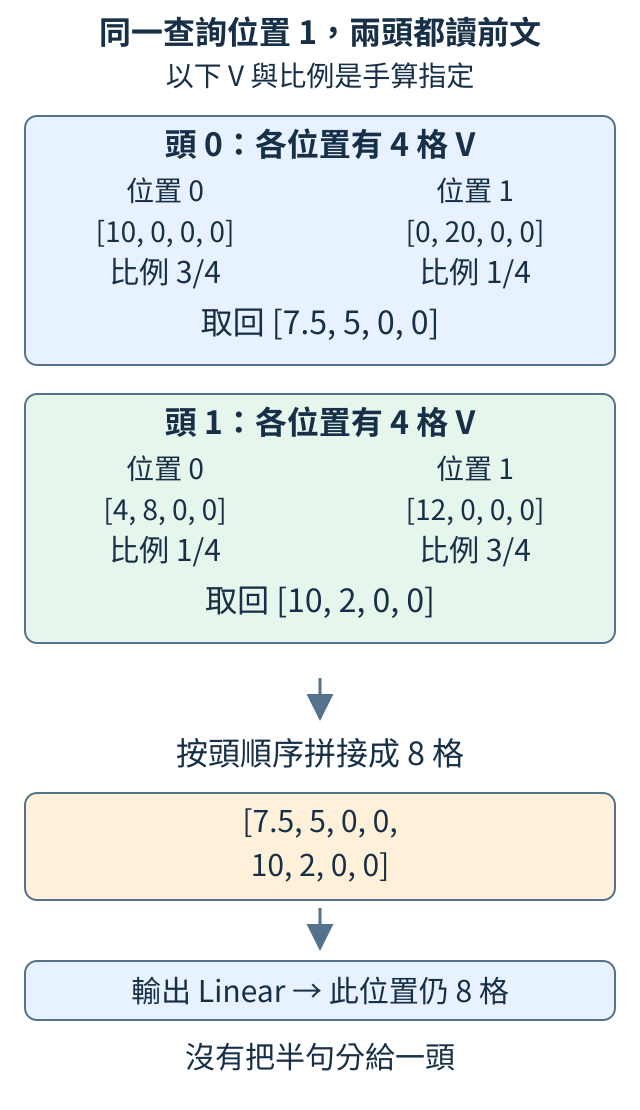

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-03-heads-output.svg")))

實際比例由各頭 Q/K 匹配產生，V 也由各自配方得到。不同頭的自由度允許不同讀法，卻沒有預設第一頭懂文法、第二頭懂物體。

下面將這個機制封裝成一層，改用四位置的隨機特徵，檢查尺寸：每位置總寬度 8，頭數 2，所以每頭 4 格。


In [3]:
import torch
from tiny_perceptron.attention import CausalAttention

torch.manual_seed(42)
layer = CausalAttention(width=8, heads=2)
x = torch.randn(1, 4, 8)
out, cache = layer(x)
print("輸出", out.shape)
print("保存的K", cache[0].shape)
assert out.shape == x.shape

輸出 torch.Size([1, 4, 8])
保存的K torch.Size([1, 2, 4, 4])


輸入 `[1,4,8]` 先經三套 Linear 產生 Q/K/V。每份最後八格分兩組四格，從 `[1,4,8]` 排成 `[1,4,2,4]`，再交換位置與頭軸，成為 `[1,2,4,4]`。每頭各有四位置，每位置四格；沒有把四位置分給不同頭。

混合後按頭拼回 `[1,4,8]`，經輸出配方，輸出仍與輸入同形狀。內容已經更新，位置數沒有增加。工具還回傳儲存的 K/V，叫**快取**，後面逐字生成可以重用；本節只印 K 的形狀 `[1,2,4,4]`。K 的最後軸是特徵，不是讀取比例表的候選位置，兩種 4 要分清。

練習把頭數 2 改成 4。總寬度不動，每頭變兩格，K 應為 `[1,4,4,2]`，輸出仍 `[1,4,8]`。頭數要整除總寬度；八格不能均分三頭。本例用亂數且未訓練，輸出或頭數的變化不提供哪個較聰明的證據。

<details>
<summary>補充與重做</summary>

種子 42 固定隨機起點，只為重現這次初始化。`CausalAttention` 包含各頭的因果許可、縮放匹配、混合 V、拼接和輸出配方。上面的指定 V 與比例是解釋輸出的手算；本節程式使用另一份隨機輸入，沒有聲稱會印出那些手算數值。

</details>
